In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 5080
12.8
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
vi_features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method', 'rdvi_noir_rgb_method', 'savi_noir_rgb_method', 'sr_noir_rgb_method','evi_noir_rgb_method', 'cigreen_noir_rgb_method' ]

features = vi_features + ['lepton_mean_temp', 'lepton_min_temp', 'lepton_max_temp']
output_variable = 'GYLD_kg_m3'

Text(0.5, 1.0, 'Train vs Test Yield Distribution')

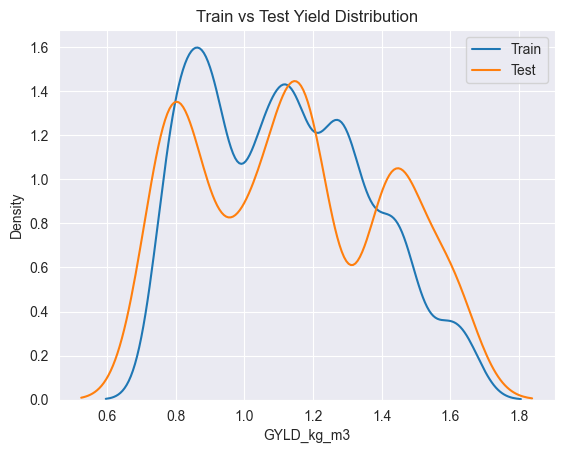

In [5]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets_v2.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets_v2.xlsx", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [7]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1084
test_df_scaled Rows with at least one NaN: 354


In [ ]:
# print(X_test_scaled.shape)

In [8]:
window_size = 30
pad_value = -99

In [10]:
from train_eval_functions import train_data
from train_eval_functions import evaluate_model

K-fold cross validation

In [ ]:
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
plot_ids = train_df['plot_id'].unique()
yield_per_plot = train_df.groupby('plot_id')[output_variable].first().values

y_bins = pd.qcut(yield_per_plot, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
from helper import make_progressive_windows
from model_definitions import GRUModel, LSTMModel
from vi_dataset import VIDataset

def k_fold_cross_validation(batch_size, k_fold_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(plot_ids, y_bins)):
        print(f"Fold {fold+1}")

        train_plots = plot_ids[train_idx]
        val_plots   = plot_ids[val_idx]

        train_df_fold = train_df[train_df['plot_id'].isin(train_plots)]
        val_df_fold   = train_df[train_df['plot_id'].isin(val_plots)]

        # Scaling
        scaler_X_fold = StandardScaler()
        scaler_y_fold = RobustScaler()

        scaler_X_fold.fit(train_df_fold[features])
        scaler_y_fold.fit(train_df_fold[[output_variable]])

        train_df_fold_scaled = train_df_fold.copy()
        val_df_fold_scaled  = val_df_fold.copy()

        train_df_fold_scaled[features] = scaler_X_fold.transform(train_df_fold[features])
        train_df_fold_scaled[output_variable] = scaler_y_fold.transform(train_df_fold[[output_variable]])

        val_df_fold_scaled[features] = scaler_X_fold.transform(val_df_fold[features])
        val_df_fold_scaled[output_variable] = scaler_y_fold.transform(val_df_fold[[output_variable]])

        X_train_fold, y_train_fold = make_progressive_windows(
            dataframe=train_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        X_val_fold, y_val_fold = make_progressive_windows(
            dataframe=val_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        train_dataset_fold = VIDataset(X_train_fold, y_train_fold)
        val_dataset_fold = VIDataset(X_val_fold, y_val_fold)

        train_loader_fold  = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
        val_loader_fold    = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)

        model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                         output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

        train_data(
            model = model,
            model_train_loader= train_loader_fold,
            num_epochs = k_fold_epochs,
            learning_rate = learning_rate,
            weight_decay = weight_decay,
            hyper_param_criterion_method = hyper_param_criterion_method,
            file_save_name=""
        )

        r2, mse = evaluate_model(
            model = model,
            val_loader = val_loader_fold,
            output_variable_scaler=scaler_y_fold)

        r2_scores.append(r2)
        print(f"Fold {fold+1} R²: {r2:.4f}")

    mean_r2 = np.mean(r2_scores)
    print(f"\n✅ Mean R² across folds: {mean_r2:.4f}")
    return mean_r2

In [12]:
import optuna
from torch.utils.data import DataLoader

search_space = {
    "hidden_size": [8, 16, 32 , 64],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "lr":  [0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [8, 16, 32, 64],
}

tuning_epochs = 500

def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = k_fold_cross_validation(
        batch_size= batch_size,
        k_fold_epochs=tuning_epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


In [ ]:
# sampler = optuna.samplers.GridSampler(search_space)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


In [13]:


cols_to_pad = ['lepton_max_temp', 'lepton_min_temp', 'lepton_mean_temp']
train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [14]:
from helper import make_progressive_windows
from vi_dataset import VIDataset

X_train_scaled, y_train_scaled = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)


train_dataset = VIDataset(X_train_scaled, y_train_scaled)
test_dataset = VIDataset(X_test_scaled, y_test_scaled)


In [15]:
from model_definitions import LSTMModel

def validation_with_test(trial_id, batch_size, num_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    train_loader_tuning  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader_tuning    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = LSTMModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1, dropout=dropout).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader_tuning,
        num_epochs = num_epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse = evaluate_model(
        model = model,
        val_loader = test_loader_tuning,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [19]:
epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        num_epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [20]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=200)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-11-06 14:34:17,666] A new study created in memory with name: no-name-5c9b0f60-c0fc-43d7-8556-9e883320d9aa


Epoch [1/1000] - Train Loss: 0.19470
Epoch [2/1000] - Train Loss: 0.17310
Epoch [3/1000] - Train Loss: 0.15088
Epoch [4/1000] - Train Loss: 0.13447
Epoch [5/1000] - Train Loss: 0.12244
Epoch [6/1000] - Train Loss: 0.11266
Epoch [7/1000] - Train Loss: 0.10993
Epoch [8/1000] - Train Loss: 0.10129
Epoch [9/1000] - Train Loss: 0.09829
Epoch [10/1000] - Train Loss: 0.09372
Epoch [11/1000] - Train Loss: 0.09118
Epoch [12/1000] - Train Loss: 0.08805
Epoch [13/1000] - Train Loss: 0.08385
Epoch [14/1000] - Train Loss: 0.08196
Epoch [15/1000] - Train Loss: 0.07921
Epoch [16/1000] - Train Loss: 0.07632
Epoch [17/1000] - Train Loss: 0.07480
Epoch [18/1000] - Train Loss: 0.07522
Epoch [19/1000] - Train Loss: 0.07376
Epoch [20/1000] - Train Loss: 0.07176
Epoch [21/1000] - Train Loss: 0.07014
Epoch [22/1000] - Train Loss: 0.07005
Epoch [23/1000] - Train Loss: 0.06912
Epoch [24/1000] - Train Loss: 0.06812
Epoch [25/1000] - Train Loss: 0.06849
Epoch [26/1000] - Train Loss: 0.06574
Epoch [27/1000] - Tra

[I 2025-11-06 14:34:28,847] Trial 0 finished with value: 0.1242666244506836 and parameters: {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.07909230201115686, 'lr': 0.0021162908887329608, 'weight_decay': 9.419829704387149e-09, 'batch_size': 64}. Best is trial 0 with value: 0.1242666244506836.


Epoch [1/1000] - Train Loss: 0.12774
Epoch [2/1000] - Train Loss: 0.09680
Epoch [3/1000] - Train Loss: 0.08335
Epoch [4/1000] - Train Loss: 0.07571
Epoch [5/1000] - Train Loss: 0.07103
Epoch [6/1000] - Train Loss: 0.07179
Epoch [7/1000] - Train Loss: 0.06911
Epoch [8/1000] - Train Loss: 0.06744
Epoch [9/1000] - Train Loss: 0.07004
Epoch [10/1000] - Train Loss: 0.06507
Epoch [11/1000] - Train Loss: 0.06296
Epoch [12/1000] - Train Loss: 0.06030
Epoch [13/1000] - Train Loss: 0.06188
Epoch [14/1000] - Train Loss: 0.05947
Epoch [15/1000] - Train Loss: 0.05751
Epoch [16/1000] - Train Loss: 0.05895
Epoch [17/1000] - Train Loss: 0.05537
Epoch [18/1000] - Train Loss: 0.05972
Epoch [19/1000] - Train Loss: 0.05718
Epoch [20/1000] - Train Loss: 0.05616
Epoch [21/1000] - Train Loss: 0.05592
Epoch [22/1000] - Train Loss: 0.05486
Epoch [23/1000] - Train Loss: 0.05436
Epoch [24/1000] - Train Loss: 0.05358
Epoch [25/1000] - Train Loss: 0.05205
Epoch [26/1000] - Train Loss: 0.05261
Epoch [27/1000] - Tra

[I 2025-11-06 14:35:03,299] Trial 1 finished with value: 0.10661596059799194 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.10463024237042717, 'lr': 0.0016445129369959597, 'weight_decay': 7.09486191801693e-06, 'batch_size': 16}. Best is trial 0 with value: 0.1242666244506836.
C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.11307761136400357 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


...

Epoch [642/1000] - Train Loss: 0.04816
Epoch [643/1000] - Train Loss: 0.04865
Epoch [644/1000] - Train Loss: 0.04933
Early stopping triggered.
 R²: 0.1723
Epoch [1/1000] - Train Loss: 0.14603
Epoch [2/1000] - Train Loss: 0.11160


C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.0008899535123544269 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch [3/1000] - Train Loss: 0.10017
Epoch [4/1000] - Train Loss: 0.08894
Epoch [5/1000] - Train Loss: 0.08291
Epoch [6/1000] - Train Loss: 0.07633
Epoch [7/1000] - Train Loss: 0.07521
Epoch [8/1000] - Train Loss: 0.07285
Epoch [9/1000] - Train Loss: 0.06774
Epoch [10/1000] - Train Loss: 0.06677
Epoch [11/1000] - Train Loss: 0.06333
Epoch [12/1000] - Train Loss: 0.06444
Epoch [13/1000] - Train Loss: 0.06134
Epoch [14/1000] - Train Loss: 0.05979
Epoch [15/1000] - Train Loss: 0.05842
Epoch [16/1000] - Train Loss: 0.05870
Epoch [17/1000] - Train Loss: 0.05644
Epoch [18/1000] - Train Loss: 0.05590
Epoch [19/1000] - Train Loss: 0.05663
Epoch [20/1000] - Train Loss: 0.05986
Epoch [21/1000] - Train Loss: 0.05519
Epoch [22/1000] - Train Loss: 0.05346
Epoch [23/1000] - Train Loss: 0.05413
Epoch [24/1000] - Train Loss: 0.05279
Epoch [25/1000] - Train Loss: 0.05200
Epoch [26/1000] - Train Loss: 0.05102
Epoch [27/1000] - Train Loss: 0.05065
Epoch [28/1000] - Train Loss: 0.05003
Epoch [29/1000] - T

[I 2025-11-06 15:44:18,390] Trial 199 finished with value: 0.2426634430885315 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0008899535123544269, 'lr': 0.001836451805506205, 'weight_decay': 0.0003666519409304001, 'batch_size': 64}. Best is trial 184 with value: 0.43634873628616333.


Epoch [110/1000] - Train Loss: 0.04314
Early stopping triggered.
 R²: 0.2427
Best R²: 0.4363
Best hyperparameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.24811930390980313, 'lr': 0.00010213391934765252, 'weight_decay': 9.374759296932881e-05, 'batch_size': 64}


In [34]:
# =============================================
#  Train the best model with best hyper params
# =============================================

# Best R²: 0.4363
# criterion_method = L1 Loss
best_lstm_params =  {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.24811930390980313, 'lr': 0.00010213391934765252, 'weight_decay': 9.374759296932881e-05, 'batch_size': 64}

best_model = LSTMModel(
    input_size=len(features),
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    output_size=1,
    dropout=best_lstm_params['dropout']).to(device)

train_loader  = DataLoader(train_dataset, batch_size=best_lstm_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_lstm_params['batch_size'], shuffle=False)

criterion_method="L1Loss"

In [35]:
# Optional: Train again with best hyper parameters


epochs = 500


train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_lstm_params['lr'],
            weight_decay = best_lstm_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru1.pth",
            early_stopping = True,
        )


Epoch [1/500] - Train Loss: 0.18852
Epoch [2/500] - Train Loss: 0.18096
Epoch [3/500] - Train Loss: 0.17461
Epoch [4/500] - Train Loss: 0.16359
Epoch [5/500] - Train Loss: 0.14320
Epoch [6/500] - Train Loss: 0.12704
Epoch [7/500] - Train Loss: 0.12080
Epoch [8/500] - Train Loss: 0.11702
Epoch [9/500] - Train Loss: 0.11387
Epoch [10/500] - Train Loss: 0.11129
Epoch [11/500] - Train Loss: 0.11032
Epoch [12/500] - Train Loss: 0.10683
Epoch [13/500] - Train Loss: 0.10552
Epoch [14/500] - Train Loss: 0.10313
Epoch [15/500] - Train Loss: 0.10196
Epoch [16/500] - Train Loss: 0.10098
Epoch [17/500] - Train Loss: 0.09923
Epoch [18/500] - Train Loss: 0.09709
Epoch [19/500] - Train Loss: 0.09708
Epoch [20/500] - Train Loss: 0.09611
Epoch [21/500] - Train Loss: 0.09560
Epoch [22/500] - Train Loss: 0.09429
Epoch [23/500] - Train Loss: 0.09284
Epoch [24/500] - Train Loss: 0.09320
Epoch [25/500] - Train Loss: 0.09118
Epoch [26/500] - Train Loss: 0.09154
Epoch [27/500] - Train Loss: 0.09080
Epoch [28/

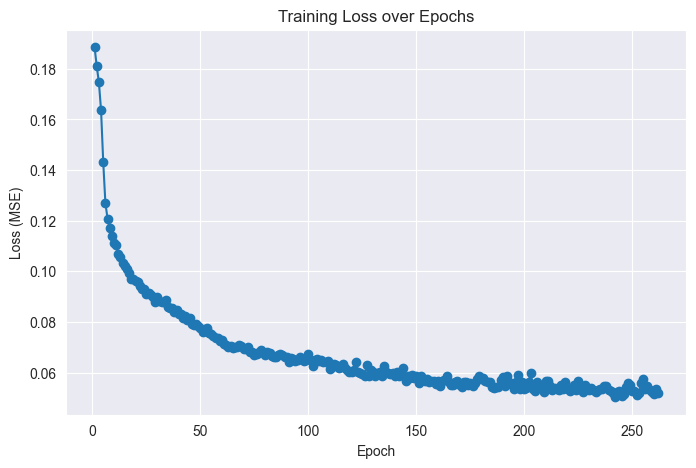

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 262+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

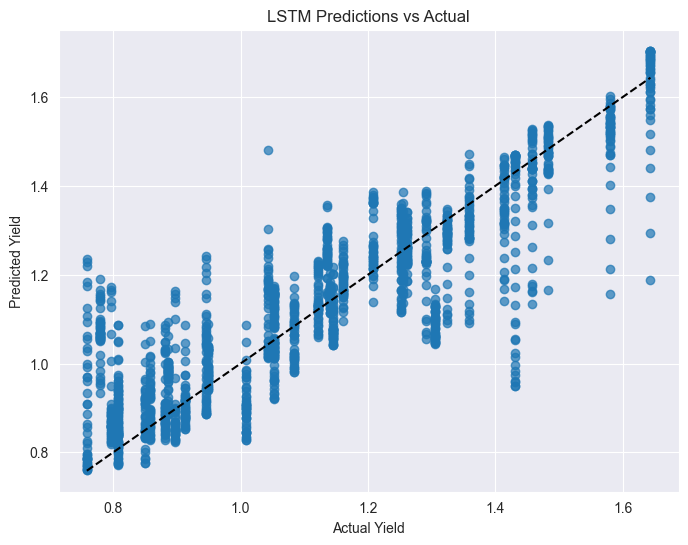

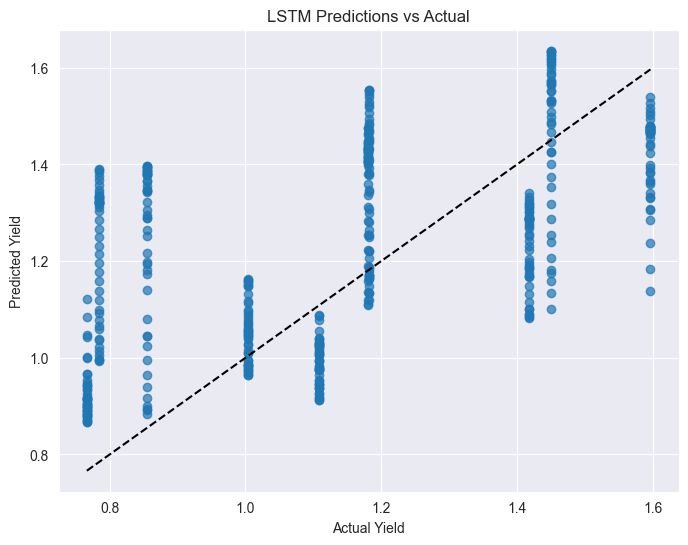

Train R²: 0.7604, Train MSE: 0.0137
Test R²: 0.1576, Test MSE: 0.0634


In [37]:
best_model.load_state_dict(torch.load("best_lstm_models/best_model_hyper_param184.pth", map_location=device))

# Training metrics
r2_train, mse_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [35]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_1.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_1.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_1.save")

['best_gru_models/scalers/scaler_y_1.save']